In [2]:
!nvidia-smi

Sun Jun 28 05:18:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import accuracy_score,classification_report, precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
import xgboost
import lightgbm
import warnings
warnings.filterwarnings("ignore")

In [4]:
import xgboost as xgb
print("Version:", xgb.__version__)

model = xgb.XGBClassifier(tree_method='hist',device='cuda')
model.fit([[0,1],[1,0]], [0,1])
print("✅ GPU training works!")

Version: 3.2.0
✅ GPU training works!


In [5]:
data1 = pd.read_excel(r"case_study1.xlsx")
data2 = pd.read_excel(r"case_study2.xlsx")

In [6]:
df1 = data1.copy()
df2 = data2.copy()

In [7]:
# overview of data

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [10]:
print(df1.shape)
df2.shape

(51336, 26)


(51336, 62)

In [11]:
# feature / variable overview

In [12]:
df2['Approved_Flag']

,Approved_Flag
0,P2
1,P2
2,P2
3,P2
4,P1
...,...
51331,P4
51332,P1
51333,P3
51334,P2


will be here later

In [13]:
# Here we can see we do not have any null values. But we have lets see

In [14]:
df1[df1['Age_Oldest_TL'] == -99999]

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
532,533,2,2,0,0,0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,2,0,2,-99999,-99999
804,805,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
1179,1180,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,1,0,0,1,0,0,-99999,-99999
3299,3300,1,1,0,0,0,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,1,1,-99999,-99999
5694,5695,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
5951,5952,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
9079,9080,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
10003,10004,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999
10859,10860,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,1,0,1,-99999,-99999
12017,12018,1,0,1,0,0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,1,1,-99999,-99999


In [15]:
# Here we have multiple -99999 values in our data ,this is the null value in our data set which is filled by -99999 number

In [16]:
# so what we will do either we will fill or remove the null values .
# But we will not fill values since i don;t have much domain knowledge i will drop the null values
# and if we have 40000 or greater than 40000 rows then we will go further if not we will try to fill the null values.

In [17]:
df1 = df1.loc[df1['Age_Oldest_TL'] != -99999]

In [18]:
for col in df1.columns:
    print(f'{col} --> {df1[df1[col] == -99999].shape[0]}')

PROSPECTID --> 0
Total_TL --> 0
Tot_Closed_TL --> 0
Tot_Active_TL --> 0
Total_TL_opened_L6M --> 0
Tot_TL_closed_L6M --> 0
pct_tl_open_L6M --> 0
pct_tl_closed_L6M --> 0
pct_active_tl --> 0
pct_closed_tl --> 0
Total_TL_opened_L12M --> 0
Tot_TL_closed_L12M --> 0
pct_tl_open_L12M --> 0
pct_tl_closed_L12M --> 0
Tot_Missed_Pmnt --> 0
Auto_TL --> 0
CC_TL --> 0
Consumer_TL --> 0
Gold_TL --> 0
Home_TL --> 0
PL_TL --> 0
Secured_TL --> 0
Unsecured_TL --> 0
Other_TL --> 0
Age_Oldest_TL --> 0
Age_Newest_TL --> 0


In [19]:
columns_to_drop = []

In [20]:
for col in df2.columns:
    print(f'{col} --> {df2[df2[col] == -99999].shape[0]}')
    if df2[df2[col] == -99999].shape[0] > 10000:
        columns_to_drop.append(col)

PROSPECTID --> 0
time_since_recent_payment --> 4291
time_since_first_deliquency --> 35949
time_since_recent_deliquency --> 35949
num_times_delinquent --> 0
max_delinquency_level --> 35949
max_recent_level_of_deliq --> 0
num_deliq_6mts --> 0
num_deliq_12mts --> 0
num_deliq_6_12mts --> 0
max_deliq_6mts --> 12890
max_deliq_12mts --> 10832
num_times_30p_dpd --> 0
num_times_60p_dpd --> 0
num_std --> 0
num_std_6mts --> 0
num_std_12mts --> 0
num_sub --> 0
num_sub_6mts --> 0
num_sub_12mts --> 0
num_dbt --> 0
num_dbt_6mts --> 0
num_dbt_12mts --> 0
num_lss --> 0
num_lss_6mts --> 0
num_lss_12mts --> 0
recent_level_of_deliq --> 0
tot_enq --> 6321
CC_enq --> 6321
CC_enq_L6m --> 6321
CC_enq_L12m --> 6321
PL_enq --> 6321
PL_enq_L6m --> 6321
PL_enq_L12m --> 6321
time_since_recent_enq --> 6321
enq_L12m --> 6321
enq_L6m --> 6321
enq_L3m --> 6321
MARITALSTATUS --> 0
EDUCATION --> 0
AGE --> 0
GENDER --> 0
NETMONTHLYINCOME --> 0
Time_With_Curr_Empr --> 0
pct_of_active_TLs_ever --> 0
pct_opened_TLs_L6m_of_L

In [21]:
columns_to_drop

['time_since_first_deliquency',
 'time_since_recent_deliquency',
 'max_delinquency_level',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'CC_utilization',
 'PL_utilization',
 'max_unsec_exposure_inPct']

In [22]:
df2 = df2.drop(columns=columns_to_drop,axis=1)

In [23]:
df2.shape

(51336, 54)

In [24]:
for col in df2.columns:
    df2 = df2.loc[df2[col] != -99999]

In [25]:
df2.shape

(42066, 54)

In [26]:
df1.isnull().sum().sum()

np.int64(0)

In [27]:
df2.isnull().sum().sum()

np.int64(0)

In [28]:
# Now i droped all the null values and i will go further if we have more than 40000 rows so we have 42000 rows, so i will go without hesitating

In [29]:
for i in list(df1.columns):
    if i in list(df2.columns):
        print(i)

PROSPECTID


In [30]:
df = df1.merge(df2,on='PROSPECTID')
df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0.0,0.0,0.000,0.0,1,0,PL,PL,696,P2
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0.0,0.0,0.000,0.0,1,0,ConsumerLoan,others,693,P2
3,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0.0,0.0,0.000,0.0,0,0,AL,AL,753,P1
4,6,6,5,1,0,0,0.000,0.0,0.167,0.833,...,1.0,0.0,0.429,0.0,1,0,ConsumerLoan,PL,668,P3


In [31]:
df.shape

(42064, 79)

In [32]:
df.isnull().sum().sum()

np.int64(0)

In [33]:
df['Approved_Flag']

,Approved_Flag
0,P2
1,P2
2,P2
3,P1
4,P3
...,...
42059,P4
42060,P1
42061,P3
42062,P2


In [34]:
# check how many categorical columns we have

In [35]:
df.select_dtypes(include='O').columns.values

array(['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2',
       'first_prod_enq2', 'Approved_Flag'], dtype=object)

In [36]:
categorical_column = ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2','first_prod_enq2']

In [37]:
for i in categorical_column:
    chi_,p_value,_,_ = chi2_contingency(pd.crosstab(df[i] , df['Approved_Flag']))
    print(f'{i} --> {p_value}')

MARITALSTATUS --> 3.578180861038862e-233
EDUCATION --> 2.6942265249737532e-30
GENDER --> 1.907936100186563e-05
last_prod_enq2 --> 0.0
first_prod_enq2 --> 7.84997610555419e-287


In [38]:
# All column have p_values less than 0.05 . we will accept all columns

In [39]:
numerical_column = []
for i in df.columns:
    if df[i].name not in (df.select_dtypes(include='O').columns):
        numerical_column.append(i)

In [40]:
numerical_column.remove('PROSPECTID')

In [41]:
numerical_column

['Total_TL',
 'Tot_Closed_TL',
 'Tot_Active_TL',
 'Total_TL_opened_L6M',
 'Tot_TL_closed_L6M',
 'pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'pct_active_tl',
 'pct_closed_tl',
 'Total_TL_opened_L12M',
 'Tot_TL_closed_L12M',
 'pct_tl_open_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'Auto_TL',
 'CC_TL',
 'Consumer_TL',
 'Gold_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'num_times_delinquent',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'tot_enq',
 'CC_enq',
 'CC_enq_L6m',
 'CC_enq_L12m',
 'PL_enq',
 'PL_enq_L6m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L12m',
 'enq_L6m',
 'enq_L3m',

In [42]:
# Now we will check is multicolinearlity exist in our dataset or not.
# If exist then we will drop that columns

In [43]:
vif_data = df[numerical_column]
total_column = vif_data.shape[1]
columns_to_be_kept = []
column_index = 0

In [44]:
for i in range(0,total_column):
    vif_value = variance_inflation_factor(vif_data,column_index)
    print(column_index , '-----', vif_value)

    if vif_value <= 6:
        columns_to_be_kept.append(numerical_column[i])
        column_index += 1

    else:
        vif_data = vif_data.drop([ numerical_column[i] ],axis=1)

0 ----- inf
0 ----- inf
0 ----- 11.320180023967996
0 ----- 8.363698035000336
0 ----- 6.520647877790928
0 ----- 5.149501618212625
1 ----- 2.611111040579735
2 ----- inf
2 ----- 1788.7926256209232
2 ----- 8.601028256477228
2 ----- 3.832800792153077
3 ----- 6.099653381646731
3 ----- 5.581352009642762
4 ----- 1.985584353098778
5 ----- inf
5 ----- 4.809538302819343
6 ----- 23.270628983464636
6 ----- 30.595522588100053
6 ----- 4.384346405965583
7 ----- 3.0646584155234238
8 ----- 2.898639771299253
9 ----- 4.377876915347322
10 ----- 2.207853583695844
11 ----- 4.916914200506864
12 ----- 5.214702030064725
13 ----- 3.3861625024231476
14 ----- 7.840583309478997
14 ----- 5.255034641721434
15 ----- inf
15 ----- 7.380634506427232
15 ----- 1.4210050015175733
16 ----- 8.083255010190316
16 ----- 1.6241227524040112
17 ----- 7.257811920140003
17 ----- 15.59624383268298
17 ----- 1.8258570471324314
18 ----- 1.5080839450032664
19 ----- 2.172088834824577
20 ----- 2.623397553527229
21 ----- 2.2959970812106163
2

In [45]:
columns_to_be_kept

['pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'Tot_TL_closed_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'CC_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'max_recent_level_of_deliq',
 'num_deliq_6_12mts',
 'num_times_60p_dpd',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'CC_enq_L12m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L3m',
 'NETMONTHLYINCOME',
 'Time_With_Curr_Empr',
 'pct_currentBal_all_TL',
 'CC_Flag',
 'PL_Flag',
 'pct_PL_enq_L6m_of_ever',
 'pct_CC_enq_L6m_of_ever',
 'HL_Flag',
 'GL_Flag']

In [46]:
columns_to_be_kept_numerical = []

for i in columns_to_be_kept:
    a = list(df[i])
    b = list(df['Approved_Flag'])

    group_p1 = [value for value,group in zip(a,b) if group == 'P1']
    group_p2 = [value for value,group in zip(a,b) if group == 'P2']
    group_p3 = [value for value,group in zip(a,b) if group == 'P3']
    group_p4 = [value for value,group in zip(a,b) if group == 'P4']

    f_stas,p_value = f_oneway(group_p1,group_p2,group_p3,group_p4)

    if p_value < 0.05:
        columns_to_be_kept_numerical.append(i)

In [47]:
columns_to_be_kept_numerical

['pct_tl_open_L6M',
 'pct_tl_closed_L6M',
 'Tot_TL_closed_L12M',
 'pct_tl_closed_L12M',
 'Tot_Missed_Pmnt',
 'CC_TL',
 'Home_TL',
 'PL_TL',
 'Secured_TL',
 'Unsecured_TL',
 'Other_TL',
 'Age_Oldest_TL',
 'Age_Newest_TL',
 'time_since_recent_payment',
 'max_recent_level_of_deliq',
 'num_deliq_6_12mts',
 'num_times_60p_dpd',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_12mts',
 'num_lss',
 'recent_level_of_deliq',
 'CC_enq_L12m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L3m',
 'NETMONTHLYINCOME',
 'Time_With_Curr_Empr',
 'CC_Flag',
 'PL_Flag',
 'pct_PL_enq_L6m_of_ever',
 'pct_CC_enq_L6m_of_ever',
 'HL_Flag',
 'GL_Flag']

In [48]:
features = columns_to_be_kept_numerical + ['MARITALSTATUS', 'EDUCATION', 'GENDER', 'last_prod_enq2','first_prod_enq2']
df = df[features + ['Approved_Flag']]

In [49]:
df.shape

(42064, 43)

In [50]:
# Label encoding for categorical columns

In [51]:
df['Approved_Flag']

,Approved_Flag
0,P2
1,P2
2,P2
3,P1
4,P3
...,...
42059,P4
42060,P1
42061,P3
42062,P2


In [52]:
df['EDUCATION'].unique()

array(['12TH', 'GRADUATE', 'SSC', 'POST-GRADUATE', 'UNDER GRADUATE',
       'OTHERS', 'PROFESSIONAL'], dtype=object)

In [53]:
df['Approved_Flag'].value_counts()

,count
Approved_Flag,
P2,25452
P3,6440
P4,5264
P1,4908


In [54]:
# ssc --> 1
# 12th and others --> 2
# Graduate and undergraduate --> 3
# Post graduate --> 4
# professional --> 3
# others has to be verified by business end user

In [55]:
df.loc[df['EDUCATION'] == '12TH', 'EDUCATION'] = 2
df.loc[df['EDUCATION'] == 'GRADUATE', 'EDUCATION'] = 3
df.loc[df['EDUCATION'] == 'SSC', 'EDUCATION'] = 1
df.loc[df['EDUCATION'] == 'POST-GRADUATE', 'EDUCATION'] = 4
df.loc[df['EDUCATION'] == 'UNDER GRADUATE', 'EDUCATION'] = 3
df.loc[df['EDUCATION'] == 'OTHERS', 'EDUCATION'] = 1
df.loc[df['EDUCATION'] == 'PROFESSIONAL', 'EDUCATION'] = 3

In [56]:
df['Approved_Flag'].value_counts()

,count
Approved_Flag,
P2,25452
P3,6440
P4,5264
P1,4908


In [57]:
df['EDUCATION'].value_counts()

,count
EDUCATION,
3,18931
2,11703
1,9532
4,1898


In [58]:
df['EDUCATION'] = df['EDUCATION'].astype('int')

In [59]:
df['EDUCATION'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 42064 entries, 0 to 42063
Series name: EDUCATION
Non-Null Count  Dtype
--------------  -----
42064 non-null  int64
dtypes: int64(1)
memory usage: 328.8 KB


In [60]:
df['Approved_Flag']

,Approved_Flag
0,P2
1,P2
2,P2
3,P1
4,P3
...,...
42059,P4
42060,P1
42061,P3
42062,P2


In [61]:
df_encoded = pd.get_dummies(df,columns=['MARITALSTATUS', 'GENDER', 'last_prod_enq2','first_prod_enq2'])

In [62]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42064 entries, 0 to 42063
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   pct_tl_open_L6M               42064 non-null  float64
 1   pct_tl_closed_L6M             42064 non-null  float64
 2   Tot_TL_closed_L12M            42064 non-null  int64  
 3   pct_tl_closed_L12M            42064 non-null  float64
 4   Tot_Missed_Pmnt               42064 non-null  int64  
 5   CC_TL                         42064 non-null  int64  
 6   Home_TL                       42064 non-null  int64  
 7   PL_TL                         42064 non-null  int64  
 8   Secured_TL                    42064 non-null  int64  
 9   Unsecured_TL                  42064 non-null  int64  
 10  Other_TL                      42064 non-null  int64  
 11  Age_Oldest_TL                 42064 non-null  int64  
 12  Age_Newest_TL                 42064 non-null  int64  
 13  t

In [63]:
df_encoded.describe().T

,count,mean,std,min,25%,50%,75%,max
pct_tl_open_L6M,42064.0,0.179032,0.278043,0.0,0.0,0.0,0.333,1.0
pct_tl_closed_L6M,42064.0,0.097783,0.210957,0.0,0.0,0.0,0.100,1.0
Tot_TL_closed_L12M,42064.0,0.825504,1.537208,0.0,0.0,0.0,1.000,33.0
pct_tl_closed_L12M,42064.0,0.160365,0.258831,0.0,0.0,0.0,0.250,1.0
Tot_Missed_Pmnt,42064.0,0.525746,1.106442,0.0,0.0,0.0,1.000,34.0
CC_TL,42064.0,0.145921,0.549314,0.0,0.0,0.0,0.000,27.0
Home_TL,42064.0,0.076241,0.358582,0.0,0.0,0.0,0.000,10.0
PL_TL,42064.0,0.328000,0.916368,0.0,0.0,0.0,0.000,29.0
Secured_TL,42064.0,2.921334,6.379764,0.0,0.0,1.0,3.000,235.0
Unsecured_TL,42064.0,2.341646,3.405397,0.0,0.0,1.0,3.000,55.0


In [64]:
df_encoded.head().T

,0,1,2,3,4
pct_tl_open_L6M,0.0,0.0,0.125,0.0,0.0
pct_tl_closed_L6M,0.0,0.0,0.0,0.0,0.0
Tot_TL_closed_L12M,0,0,0,0,1
pct_tl_closed_L12M,0.0,0.0,0.0,0.0,0.167
Tot_Missed_Pmnt,0,0,1,0,0
CC_TL,0,0,0,0,0
Home_TL,0,0,0,0,0
PL_TL,4,0,0,0,0
Secured_TL,1,0,2,3,6
Unsecured_TL,4,1,6,0,0


In [65]:
# Data Preprocessing

In [66]:
df_encoded

,pct_tl_open_L6M,pct_tl_closed_L6M,Tot_TL_closed_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,CC_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,...,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_AL,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
0,0.000,0.00,0,0.000,0,0,0,4,1,4,...,False,False,True,False,False,False,False,False,True,False
1,0.000,0.00,0,0.000,0,0,0,0,0,1,...,True,False,False,False,False,False,True,False,False,False
2,0.125,0.00,0,0.000,1,0,0,0,2,6,...,True,False,False,False,False,False,False,False,False,True
3,0.000,0.00,0,0.000,0,0,0,0,3,0,...,False,False,False,False,True,False,False,False,False,False
4,0.000,0.00,1,0.167,0,0,0,0,6,0,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42059,0.333,0.00,0,0.000,0,0,0,0,0,3,...,True,False,False,False,False,False,True,False,False,False
42060,0.000,0.25,1,0.250,0,0,0,0,2,2,...,False,False,False,True,False,False,False,False,False,True
42061,0.500,0.50,1,0.500,0,0,0,0,0,2,...,True,False,False,False,False,False,False,False,False,True
42062,0.000,0.00,1,0.500,0,0,0,0,0,2,...,True,False,False,False,False,False,False,False,False,True


In [67]:
y = df_encoded['Approved_Flag']
x = df_encoded.drop(['Approved_Flag'],axis=1)

In [68]:
x_train,x_test,y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

### Model Training

In [69]:
# 1. Random forest

rfc = RandomForestClassifier(n_estimators=100,random_state=42)
rfc.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [70]:
from sklearn.metrics import accuracy_score, classification_report

In [71]:
y_pred = rfc.predict(x_test)

In [72]:
accuracy_score(y_pred,y_test)

0.7644122191845952

In [73]:
print("Accurcay on test : ",accuracy_score(rfc.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(rfc.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(rfc.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(rfc.predict(x_test),y_test))

Accurcay on test :  0.7644122191845952
Accurcay on train :  0.9999702832010936
Classification report on train : 
               precision    recall  f1-score   support

          P1       1.00      1.00      1.00      3894
          P2       1.00      1.00      1.00     20408
          P3       1.00      1.00      1.00      5114
          P4       1.00      1.00      1.00      4235

    accuracy                           1.00     33651
   macro avg       1.00      1.00      1.00     33651
weighted avg       1.00      1.00      1.00     33651

Classification report on test : 
               precision    recall  f1-score   support

          P1       0.70      0.83      0.76       856
          P2       0.93      0.80      0.86      5881
          P3       0.22      0.46      0.30       645
          P4       0.72      0.72      0.72      1031

    accuracy                           0.76      8413
   macro avg       0.64      0.70      0.66      8413
weighted avg       0.83      0.76    

In [74]:
# xgboost

In [75]:
y_xgb = df_encoded['Approved_Flag']
x_xgb = df_encoded.drop(['Approved_Flag'],axis=1)

In [76]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_xgb)

In [77]:
x_train_xgb,x_test_xgb,y_train_xgb,y_test_xgb = train_test_split(x_xgb,y_encoded,random_state=42,test_size=0.2)

In [78]:
xgb_classifier = xgboost.XGBClassifier(objective='multi:soft_max',num_class=4,tree_method='hist',device='cuda' )

In [79]:
xgb_classifier.fit(x_train_xgb,y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=4, ...)

In [80]:
y_pred_xgb = xgb_classifier.predict(x_test)

In [81]:
accuracy_score(y_pred_xgb,y_test_xgb)

0.775466539878759

In [82]:
print("Accurcay on test : ",accuracy_score(xgb_classifier.predict(x_test_xgb),y_test_xgb))
print("Accurcay on train : ",accuracy_score(xgb_classifier.predict(x_train_xgb),y_train_xgb))
print("Classification report on train : \n",classification_report(xgb_classifier.predict(x_train_xgb),y_train_xgb))
print("Classification report on test : \n",classification_report(xgb_classifier.predict(x_test_xgb),y_test_xgb))

Accurcay on test :  0.775466539878759
Accurcay on train :  0.8932572583281329
Classification report on train : 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      3809
           1       0.97      0.90      0.93     21939
           2       0.59      0.79      0.67      3804
           3       0.89      0.92      0.90      4099

    accuracy                           0.89     33651
   macro avg       0.84      0.89      0.86     33651
weighted avg       0.91      0.89      0.90     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       938
           1       0.91      0.82      0.87      5587
           2       0.29      0.47      0.36       834
           3       0.74      0.72      0.73      1054

    accuracy                           0.78      8413
   macro avg       0.68      0.71      0.69      8413
weighted avg       0.81      0.78     

In [83]:
# Decision tree

In [84]:
dt_classifier = DecisionTreeClassifier(max_depth=20,min_samples_split=10)


In [85]:
dt_classifier.fit(x_train,y_train)
y_pred_dt = dt_classifier.predict(x_test)

In [86]:
accuracy_score(y_pred_dt,y_test)

0.711042434327826

In [87]:
print("Accurcay on test : ",accuracy_score(dt_classifier.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(dt_classifier.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(dt_classifier.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(dt_classifier.predict(x_test),y_test))

Accurcay on test :  0.711042434327826
Accurcay on train :  0.9123948768238686
Classification report on train : 
               precision    recall  f1-score   support

          P1       0.94      0.91      0.93      4017
          P2       0.96      0.93      0.95     20949
          P3       0.76      0.82      0.78      4743
          P4       0.85      0.92      0.89      3942

    accuracy                           0.91     33651
   macro avg       0.88      0.89      0.89     33651
weighted avg       0.92      0.91      0.91     33651

Classification report on test : 
               precision    recall  f1-score   support

          P1       0.73      0.73      0.73      1009
          P2       0.83      0.81      0.82      5153
          P3       0.32      0.35      0.33      1243
          P4       0.63      0.64      0.64      1008

    accuracy                           0.71      8413
   macro avg       0.63      0.63      0.63      8413
weighted avg       0.72      0.71     

In [88]:
# Now moving towards to build recall oriented model.

# I will take Random forest first and build a complex model if it gives better result will choose this other wise i will move towards Boosting algorithm.

In [89]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

In [90]:
weights

array([2.16043914, 0.41224825, 1.64472141, 1.9864817 ])

In [91]:
rfc = RandomForestClassifier(
    n_estimators=500,
    max_depth=16,
    min_samples_leaf=10,
    class_weight=class_weight_dict,
    random_state=42
)

In [92]:
rfc.fit(x_train,y_train)

RandomForestClassifier(class_weight={'P1': np.float64(2.1604391371340523),
                                     'P2': np.float64(0.41224824815014455),
                                     'P3': np.float64(1.6447214076246335),
                                     'P4': np.float64(1.9864817001180637)},
                       max_depth=16, min_samples_leaf=10, n_estimators=500,
                       random_state=42)

In [93]:
print("Accurcay on test : ",accuracy_score(rfc.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(rfc.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(rfc.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(rfc.predict(x_test),y_test))

Accurcay on test :  0.7040294781885178
Accurcay on train :  0.7828890671896823
Classification report on train : 
               precision    recall  f1-score   support

          P1       0.98      0.65      0.78      5844
          P2       0.73      0.97      0.84     15458
          P3       0.74      0.52      0.61      7301
          P4       0.89      0.74      0.81      5048

    accuracy                           0.78     33651
   macro avg       0.84      0.72      0.76     33651
weighted avg       0.80      0.78      0.77     33651

Classification report on test : 
               precision    recall  f1-score   support

          P1       0.93      0.63      0.75      1494
          P2       0.69      0.91      0.79      3830
          P3       0.53      0.38      0.44      1827
          P4       0.77      0.63      0.69      1262

    accuracy                           0.70      8413
   macro avg       0.73      0.64      0.67      8413
weighted avg       0.71      0.70    

In [94]:
# Random forest is not improving even after changing n_estimator value from 100 to 300 to 500. Even after tweaking tree_depth.
# Now i will make some changes in xgboost

### Hyper parameter tuning.

In [95]:
from xgboost import XGBClassifier

In [96]:
import numpy as np

# Give more weight to P3 (class 2) and P4 (class 3)
sample_weights = np.ones(len(y_train))
sample_weights[y_train == 2] = 4.0
sample_weights[y_train == 3] = 2.5

In [97]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=1,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(x_train_xgb, y_train_xgb,sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [98]:
print("Accurcay on test : ",accuracy_score(xgb_classifier.predict(x_test_xgb),y_test_xgb))
print("Accurcay on train : ",accuracy_score(xgb_classifier.predict(x_train_xgb),y_train_xgb))
print("Classification report on train : \n",classification_report(xgb_classifier.predict(x_train_xgb),y_train_xgb))
print("Classification report on test : \n",classification_report(xgb_classifier.predict(x_test_xgb),y_test_xgb))

Accurcay on test :  0.775466539878759
Accurcay on train :  0.8932572583281329
Classification report on train : 
               precision    recall  f1-score   support

           0       0.92      0.94      0.93      3809
           1       0.97      0.90      0.93     21939
           2       0.59      0.79      0.67      3804
           3       0.89      0.92      0.90      4099

    accuracy                           0.89     33651
   macro avg       0.84      0.89      0.86     33651
weighted avg       0.91      0.89      0.90     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.76      0.82      0.79       938
           1       0.91      0.82      0.87      5587
           2       0.29      0.47      0.36       834
           3       0.74      0.72      0.73      1054

    accuracy                           0.78      8413
   macro avg       0.68      0.71      0.69      8413
weighted avg       0.81      0.78     

In [99]:
import numpy as np
from sklearn.metrics import classification_report

# Get probabilities from your best model
proba = xgb.predict_proba(x_test_xgb)   # shape: (n_samples, 4)
# columns: [P1_prob, P2_prob, P3_prob, P4_prob]

# Try different thresholds for P3 (column index 2)
for thresh in [0.20, 0.25, 0.30, 0.35]:
    preds = []
    for p in proba:
        if p[3] >= 0.40:        # P4 check first
            preds.append(3)
        elif p[2] >= thresh:    # P3 with lower threshold
            preds.append(2)
        else:
            preds.append(np.argmax(p))

    print(f"\n--- P3 threshold = {thresh} ---")
    print(classification_report(y_test_xgb, preds,
          target_names=['P1','P2','P3','P4']))


--- P3 threshold = 0.2 ---
              precision    recall  f1-score   support

          P1       0.81      0.76      0.78      1014
          P2       0.88      0.77      0.82      5045
          P3       0.39      0.57      0.46      1325
          P4       0.72      0.76      0.74      1029

    accuracy                           0.74      8413
   macro avg       0.70      0.72      0.70      8413
weighted avg       0.77      0.74      0.75      8413


--- P3 threshold = 0.25 ---
              precision    recall  f1-score   support

          P1       0.81      0.76      0.78      1014
          P2       0.86      0.81      0.83      5045
          P3       0.40      0.49      0.44      1325
          P4       0.72      0.76      0.74      1029

    accuracy                           0.75      8413
   macro avg       0.70      0.71      0.70      8413
weighted avg       0.77      0.75      0.76      8413


--- P3 threshold = 0.3 ---
              precision    recall  f1-score  

In [100]:
lgbm = lightgbm.LGBMClassifier(
    device='gpu',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=500
)

In [101]:
lgbm.fit(x_train,y_train)

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 33651, number of used features: 54
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 16 dense feature groups (0.51 MB) transferred to GPU in 0.001733 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score -2.156606
[LightGBM] [Info] Start training from score -0.500165
[LightGBM] [Info] Start training from score -1.883865
[LightGBM] [Info] Start training from score -2.072659


LGBMClassifier(device='gpu', learning_rate=0.05, n_estimators=500)

In [102]:
print("Accurcay on test : ",accuracy_score(lgbm.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(lgbm.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(lgbm.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(lgbm.predict(x_test),y_test))

Accurcay on test :  0.7766551765125401
Accurcay on train :  0.9144156191495052
Classification report on train : 
               precision    recall  f1-score   support

          P1       0.94      0.96      0.95      3823
          P2       0.98      0.91      0.94     21851
          P3       0.65      0.86      0.74      3830
          P4       0.92      0.94      0.93      4147

    accuracy                           0.91     33651
   macro avg       0.87      0.92      0.89     33651
weighted avg       0.93      0.91      0.92     33651

Classification report on test : 
               precision    recall  f1-score   support

          P1       0.77      0.83      0.80       942
          P2       0.92      0.82      0.87      5612
          P3       0.29      0.46      0.35       836
          P4       0.73      0.74      0.73      1023

    accuracy                           0.78      8413
   macro avg       0.68      0.71      0.69      8413
weighted avg       0.81      0.78    

In [103]:
# Manual class weights — boost P3 hard
class_weight_map = {0: 1.0, 1: 1.0, 2: 5.0, 3: 2.5}

lgbm = lightgbm.LGBMClassifier(
    boosting_type='gbdt',
    num_leaves=63,
    learning_rate=0.05,
    n_estimators=500,
    class_weight=class_weight_map,
    random_state=42
)
lgbm.fit(x_train, y_train_xgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020308 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3028
[LightGBM] [Info] Number of data points in the train set: 33651, number of used features: 54
[LightGBM] [Info] Start training from score -2.742603
[LightGBM] [Info] Start training from score -1.086162
[LightGBM] [Info] Start training from score -0.860425
[LightGBM] [Info] Start training from score -1.742366


LGBMClassifier(class_weight={0: 1.0, 1: 1.0, 2: 5.0, 3: 2.5},
               learning_rate=0.05, n_estimators=500, num_leaves=63,
               random_state=42)

In [104]:
print("Accurcay on test : ",accuracy_score(lgbm.predict(x_test),y_test_xgb))
print("Accurcay on train : ",accuracy_score(lgbm.predict(x_train),y_train_xgb))
print("Classification report on train : \n",classification_report(lgbm.predict(x_train),y_train_xgb))
print("Classification report on test : \n",classification_report(lgbm.predict(x_test),y_test_xgb))

Accurcay on test :  0.7487222156186853
Accurcay on train :  0.9518587857715967
Classification report on train : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3878
           1       0.93      1.00      0.96     18996
           2       1.00      0.77      0.87      6593
           3       0.98      0.99      0.99      4184

    accuracy                           0.95     33651
   macro avg       0.97      0.94      0.95     33651
weighted avg       0.95      0.95      0.95     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.77      0.82      0.79       950
           1       0.81      0.87      0.84      4719
           2       0.56      0.40      0.47      1830
           3       0.68      0.77      0.72       914

    accuracy                           0.75      8413
   macro avg       0.70      0.71      0.70      8413
weighted avg       0.74      0.75    

In [105]:
import pandas as pd
import numpy as np

# Check how different P3 looks from other classes
# Replace 'df' and 'target' with your actual dataframe and target column name

print("=== Class-wise feature means ===")
print(df.groupby('Approved_Flag').mean(numeric_only=True).round(2).T.to_string())

print("\n=== P3 support across splits ===")
print("Train P3 count:", (y_train == 2).sum())
print("Test  P3 count:", (y_test  == 2).sum())
print("Train P3 %:", round((y_train == 2).mean() * 100, 2))
print("Test  P3 %:", round((y_test  == 2).mean() * 100, 2))

=== Class-wise feature means ===
Approved_Flag                    P1        P2        P3        P4
pct_tl_open_L6M                0.08      0.16      0.25      0.30
pct_tl_closed_L6M              0.06      0.10      0.11      0.12
Tot_TL_closed_L12M             1.24      0.74      0.77      0.92
pct_tl_closed_L12M             0.11      0.16      0.17      0.18
Tot_Missed_Pmnt                0.94      0.43      0.48      0.64
CC_TL                          0.26      0.12      0.14      0.16
Home_TL                        0.27      0.06      0.04      0.03
PL_TL                          0.71      0.26      0.26      0.41
Secured_TL                     6.91      2.42      2.18      2.51
Unsecured_TL                   3.21      2.10      2.29      2.79
Other_TL                       2.88      0.92      0.81      0.81
Age_Oldest_TL                112.10     40.97     32.53     29.16
Age_Newest_TL                 16.73     14.67     12.14     10.23
time_since_recent_payment    312.77    220.

In [106]:
print(df['Approved_Flag'].value_counts())
print()
print(df['Approved_Flag'].value_counts(normalize=True).round(3) * 100)

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64

Approved_Flag
P2    60.5
P3    15.3
P4    12.5
P1    11.7
Name: proportion, dtype: float64


In [107]:
# Enquiry pressure score — P3 has high recent enquiries
df['enq_pressure'] = df['enq_L3m'] / (df['time_since_recent_enq'] + 1)

# Delinquency-to-income ratio
df['deliq_income_ratio'] = df['max_recent_level_of_deliq'] / (df['NETMONTHLYINCOME'] + 1)

# Loan seeking behavior — P3 seeks more PL recently
df['PL_seeking'] = df['pct_PL_enq_L6m_of_ever'] * df['PL_enq_L12m']

# Recent stress indicator
df['recent_stress'] = df['num_deliq_6_12mts'] + df['num_times_60p_dpd']

# Time pressure — how recently are they borrowing?
df['borrow_recency'] = 1 / (df['time_since_recent_enq'] + 1)

In [108]:
new_features = ['enq_pressure','deliq_income_ratio',
                'PL_seeking','recent_stress','borrow_recency']

print(df.groupby('Approved_Flag')[new_features].mean().round(4).T.to_string())

Approved_Flag           P1      P2      P3      P4
enq_pressure        0.0653  0.1108  0.2709  0.8102
deliq_income_ratio  0.0026  0.0088  0.0748  0.0681
PL_seeking          0.1040  0.2275  0.6399  1.7268
recent_stress       0.8712  0.6005  0.9110  1.3693
borrow_recency      0.0454  0.0712  0.1291  0.1718


In [109]:
# Now adding new feature at encoded column

In [110]:
# Enquiry pressure score — P3 has high recent enquiries
df_encoded['enq_pressure'] = df_encoded['enq_L3m'] / (df_encoded['time_since_recent_enq'] + 1)

# Delinquency-to-income ratio
df_encoded['deliq_income_ratio'] = df_encoded['max_recent_level_of_deliq'] / (df_encoded['NETMONTHLYINCOME'] + 1)

# Loan seeking behavior — P3 seeks more PL recently
df_encoded['PL_seeking'] = df_encoded['pct_PL_enq_L6m_of_ever'] * df_encoded['PL_enq_L12m']

# Recent stress indicator
df_encoded['recent_stress'] = df_encoded['num_deliq_6_12mts'] + df_encoded['num_times_60p_dpd']

# Time pressure — how recently are they borrowing?
df_encoded['borrow_recency'] = 1 / (df_encoded['time_since_recent_enq'] + 1)

In [111]:
y = df_encoded['Approved_Flag']
x = df_encoded.drop(['Approved_Flag'],axis=1)

In [112]:
x_train,x_test,y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [113]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [114]:
x_train_xgb,x_test_xgb,y_train_xgb,y_test_xgb = train_test_split(x,y_encoded,random_state=42,test_size=0.2)

In [115]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=1,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(x_train_xgb, y_train_xgb,sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [116]:
print("Accurcay on test : ",accuracy_score(xgb.predict(x_test_xgb),y_test_xgb))
print("Accurcay on train : ",accuracy_score(xgb.predict(x_train_xgb),y_train_xgb))
print("Classification report on train : \n",classification_report(xgb.predict(x_train_xgb),y_train_xgb))
print("Classification report on test : \n",classification_report(xgb.predict(x_test_xgb),y_test_xgb))

Accurcay on test :  0.7716629026506597
Accurcay on train :  0.9522451041573802
Classification report on train : 
               precision    recall  f1-score   support

           0       0.97      0.98      0.98      3851
           1       0.99      0.94      0.97     21381
           2       0.78      0.93      0.85      4284
           3       0.96      0.99      0.98      4135

    accuracy                           0.95     33651
   macro avg       0.93      0.96      0.94     33651
weighted avg       0.96      0.95      0.95     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.76      0.81      0.78       942
           1       0.91      0.82      0.86      5577
           2       0.30      0.46      0.36       859
           3       0.73      0.73      0.73      1035

    accuracy                           0.77      8413
   macro avg       0.67      0.71      0.68      8413
weighted avg       0.81      0.77    

In [117]:
print(df['Approved_Flag'].value_counts())

Approved_Flag
P2    25452
P3     6440
P4     5264
P1     4908
Name: count, dtype: int64


In [118]:
p3 = df[df['Approved_Flag'] == 'P3']
p2 = df[df['Approved_Flag'] == 'P2']
p4 = df[df['Approved_Flag'] == 'P4']

print("P3 samples:", len(p3))
print("P2 samples:", len(p2))
print("P4 samples:", len(p4))

P3 samples: 6440
P2 samples: 25452
P4 samples: 5264


In [119]:
p2_max = p2['enq_L3m'].quantile(0.75)
p3_inside_p2 = (p3['enq_L3m'] <= p2_max).sum()

print(f"P3 samples that look like P2 on enq_L3m: {p3_inside_p2} out of {len(p3)}")
print(f"That is {round(p3_inside_p2/len(p3)*100, 1)}% of all P3 samples")

P3 samples that look like P2 on enq_L3m: 3578 out of 6440
That is 55.6% of all P3 samples


In [120]:
p4_max = p4['enq_L3m'].quantile(0.75)
p3_inside_p4 = (p3['enq_L3m'] <= p4_max).sum()

print(f"P3 samples that look like P4 on enq_L3m: {p3_inside_p4} out of {len(p3)}")
print(f"That is {round(p3_inside_p4/len(p3)*100, 1)}% of all P3 samples")

P3 samples that look like P4 on enq_L3m: 6405 out of 6440
That is 99.5% of all P3 samples


In [121]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

df_temp = df.copy()
df_temp['target_encoded'] = LabelEncoder().fit_transform(df['Approved_Flag'])

correlations = df_temp.corr(numeric_only=True)['target_encoded'].drop('target_encoded')
print(correlations.abs().sort_values(ascending=False).head(15))

enq_L3m                   0.535425
Age_Oldest_TL             0.404561
pct_PL_enq_L6m_of_ever    0.401189
enq_pressure              0.367570
PL_seeking                0.361967
PL_enq_L12m               0.314367
num_std_12mts             0.313952
time_since_recent_enq     0.308924
borrow_recency            0.240453
pct_tl_open_L6M           0.226902
CC_enq_L12m               0.185473
pct_CC_enq_L6m_of_ever    0.184552
Other_TL                  0.160485
Time_With_Curr_Empr       0.150504
Home_TL                   0.131988
Name: target_encoded, dtype: float64


In [122]:
# By seeing this , I can say that P3 is hard to predict because it shows 55% similarity with P2 and 99.5% with P4. So it's better to convert this problem into binary problem.

In [123]:
df_encoded['target_binary'] = df_encoded['Approved_Flag'].map({
    'P1': 0,
    'P2': 0,
    'P3': 1,
    'P4': 1
})

In [124]:
df_encoded['target_binary'].value_counts()

,count
target_binary,
0,30360
1,11704


In [125]:
df_encoded.drop('Approved_Flag',axis=1,inplace=True)

In [126]:
x = df_encoded.drop('target_binary',axis=1)
y = df_encoded['target_binary']

In [127]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
lr = LogisticRegression()
lr.fit(x_train,y_train)

LogisticRegression()

In [130]:
print("Accurcay on test : ",accuracy_score(lr.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(lr.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(lr.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(lr.predict(x_test),y_test))

Accurcay on test :  0.8145726851301557
Accurcay on train :  0.8132002020742326
Classification report on train : 
               precision    recall  f1-score   support

           0       0.94      0.82      0.88     27851
           1       0.47      0.76      0.59      5800

    accuracy                           0.81     33651
   macro avg       0.71      0.79      0.73     33651
weighted avg       0.86      0.81      0.83     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.94      0.83      0.88      6883
           1       0.49      0.76      0.60      1530

    accuracy                           0.81      8413
   macro avg       0.72      0.79      0.74      8413
weighted avg       0.86      0.81      0.83      8413



In [131]:
rf = RandomForestClassifier(n_estimators=100,max_depth=6,random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(max_depth=6, random_state=42)

In [132]:
print("Accurcay on test : ",accuracy_score(rf.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(rf.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(rf.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(rf.predict(x_test),y_test))

Accurcay on test :  0.8580767859265422
Accurcay on train :  0.8615791506938872
Classification report on train : 
               precision    recall  f1-score   support

           0       0.95      0.87      0.91     26541
           1       0.63      0.83      0.72      7110

    accuracy                           0.86     33651
   macro avg       0.79      0.85      0.81     33651
weighted avg       0.88      0.86      0.87     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.95      0.87      0.91      6605
           1       0.63      0.82      0.71      1808

    accuracy                           0.86      8413
   macro avg       0.79      0.84      0.81      8413
weighted avg       0.88      0.86      0.86      8413



In [133]:
xgb = xgboost.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.01,
    scale_pos_weight=1,
    tree_method='hist',
    device='cuda',
    random_state=42)

xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [134]:
print("Accurcay on test : ",accuracy_score(xgb.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(xgb.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(xgb.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(xgb.predict(x_test),y_test))

Accurcay on test :  0.8709140615713776
Accurcay on train :  0.9005378740602062
Classification report on train : 
               precision    recall  f1-score   support

           0       0.96      0.91      0.93     25652
           1       0.75      0.88      0.81      7999

    accuracy                           0.90     33651
   macro avg       0.85      0.89      0.87     33651
weighted avg       0.91      0.90      0.90     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.94      0.89      0.91      6399
           1       0.70      0.81      0.75      2014

    accuracy                           0.87      8413
   macro avg       0.82      0.85      0.83      8413
weighted avg       0.88      0.87      0.87      8413



In [169]:
# Lightbgm
lgbm = lightgbm.LGBMClassifier(
    device='gpu',
    boosting_type='gbdt',
    num_leaves=61,
    learning_rate=0.05,
    n_estimators=300
)

In [170]:
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Number of positive: 9350, number of negative: 24301
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 4029
[LightGBM] [Info] Number of data points in the train set: 33651, number of used features: 59
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 18 dense feature groups (0.64 MB) transferred to GPU in 0.001391 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.277852 -> initscore=-0.955141
[LightGBM] [Info] Start training from score -0.955141


LGBMClassifier(device='gpu', learning_rate=0.05, n_estimators=300,
               num_leaves=61)

In [171]:
print("Accurcay on test : ",accuracy_score(lgbm.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(lgbm.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(lgbm.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(lgbm.predict(x_test),y_test))

Accurcay on test :  0.8756686081065018
Accurcay on train :  0.9320673976999198
Classification report on train : 
               precision    recall  f1-score   support

           0       0.97      0.93      0.95     25309
           1       0.82      0.92      0.87      8342

    accuracy                           0.93     33651
   macro avg       0.90      0.93      0.91     33651
weighted avg       0.94      0.93      0.93     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      6339
           1       0.72      0.82      0.76      2074

    accuracy                           0.88      8413
   macro avg       0.83      0.86      0.84      8413
weighted avg       0.88      0.88      0.88      8413



In [172]:
# Threshold tuning on 1st lgbm model
from sklearn.metrics import classification_report, recall_score
lgbm_proba = lgbm.predict_proba(x_test)[:, 1]

print("=== THRESHOLD TUNING ===")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (lgbm_proba >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    acc = (preds == y_test).mean()
    print(f"Threshold {thresh} → Recall: {r:.2f}  "
          f"Precision: {p:.2f}  Accuracy: {acc:.2f}")

=== THRESHOLD TUNING ===
Threshold 0.25 → Recall: 0.87  Precision: 0.68  Accuracy: 0.85
Threshold 0.3 → Recall: 0.83  Precision: 0.72  Accuracy: 0.86
Threshold 0.35 → Recall: 0.80  Precision: 0.74  Accuracy: 0.87
Threshold 0.4 → Recall: 0.77  Precision: 0.77  Accuracy: 0.87
Threshold 0.45 → Recall: 0.74  Precision: 0.79  Accuracy: 0.87
Threshold 0.5 → Recall: 0.72  Precision: 0.82  Accuracy: 0.88


In [ ]:
# Hyper parameter tuning of Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parameter grid
param_dist = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [6, 8, 10, 12],
    'min_samples_leaf': [5, 10, 20],
    'class_weight'    : [
                         {0:1, 1:2},
                         {0:1, 1:3},
                         {0:1, 1:4},
                         'balanced'
                        ]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=20,           # tries 20 random combinations
    scoring='recall',    # optimize for catching defaulters
    cv=3,
    random_state=42,
    verbose=5
)

search.fit(x_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV Recall :", search.best_score_.round(4))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV 1/3] END class_weight=balanced, max_depth=8, min_samples_leaf=5, n_estimators=100;, score=0.823 total time=   1.5s
[CV 2/3] END class_weight=balanced, max_depth=8, min_samples_leaf=5, n_estimators=100;, score=0.831 total time=   1.5s
[CV 3/3] END class_weight=balanced, max_depth=8, min_samples_leaf=5, n_estimators=100;, score=0.826 total time=   1.5s
[CV 1/3] END class_weight={0: 1, 1: 2}, max_depth=10, min_samples_leaf=5, n_estimators=200;, score=0.779 total time=   4.2s
[CV 2/3] END class_weight={0: 1, 1: 2}, max_depth=10, min_samples_leaf=5, n_estimators=200;, score=0.772 total time=   4.4s
[CV 3/3] END class_weight={0: 1, 1: 2}, max_depth=10, min_samples_leaf=5, n_estimators=200;, score=0.783 total time=   3.6s
[CV 1/3] END class_weight={0: 1, 1: 4}, max_depth=8, min_samples_leaf=5, n_estimators=200;, score=0.910 total time=   2.9s
[CV 2/3] END class_weight={0: 1, 1: 4}, max_depth=8, min_samples_leaf=5, n_estimators=2

In [ ]:
# Get best model
rf_tuned = search.best_estimator_

y_train_pred = rf_tuned.predict(x_train)
y_test_pred  = rf_tuned.predict(x_test)

print("=== TUNED RANDOM FOREST ===")
print(f"Train Accuracy : {(y_train_pred == y_train).mean():.4f}")
print(f"Test  Accuracy : {(y_test_pred  == y_test ).mean():.4f}")

print("\nTrain Report:")
print(classification_report(y_train, y_train_pred,
      target_names=['Low Risk','High Risk']))

print("Test Report:")
print(classification_report(y_test, y_test_pred,
      target_names=['Low Risk','High Risk']))

# Threshold tuning on tuned model
rf_tuned_proba = rf_tuned.predict_proba(x_test)[:, 1]

print("=== THRESHOLD TUNING ===")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (rf_tuned_proba >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    acc = (preds == y_test).mean()
    print(f"Threshold {thresh} → Recall: {r:.2f}  "
          f"Precision: {p:.2f}  Accuracy: {acc:.2f}")

=== TUNED RANDOM FOREST ===
Train Accuracy : 0.7539
Test  Accuracy : 0.7481

Train Report:
              precision    recall  f1-score   support

    Low Risk       0.97      0.68      0.80     24301
   High Risk       0.53      0.94      0.68      9350

    accuracy                           0.75     33651
   macro avg       0.75      0.81      0.74     33651
weighted avg       0.85      0.75      0.77     33651

Test Report:
              precision    recall  f1-score   support

    Low Risk       0.96      0.68      0.79      6059
   High Risk       0.53      0.93      0.67      2354

    accuracy                           0.75      8413
   macro avg       0.74      0.80      0.73      8413
weighted avg       0.84      0.75      0.76      8413

=== THRESHOLD TUNING ===
Threshold 0.25 → Recall: 0.97  Precision: 0.40  Accuracy: 0.58
Threshold 0.3 → Recall: 0.97  Precision: 0.41  Accuracy: 0.60
Threshold 0.35 → Recall: 0.97  Precision: 0.42  Accuracy: 0.62
Threshold 0.4 → Recall: 0.96 

In [ ]:
# Hyper parameter tuning of xgboost
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, recall_score
import numpy as np

# Parameter grid
param_dist = {
    'n_estimators'    : [100, 200, 300, 500, 800],
    'max_depth'       : [6, 8, 10, 12],
    'learning_rate'   : [0.01, 0.05,0.1]
}

xgb_base = xgboost.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.01,
    scale_pos_weight=1,
    tree_method='hist',
    device='cuda',
    random_state=42)

search = GridSearchCV(
    xgb_base,
    param_grid=param_dist,
    scoring='recall',    # optimize for catching defaulters
    cv=3,
    verbose=7
)

search.fit(x_train, y_train)

print("Best Parameters:", search.best_params_)
print("Best CV Recall :", search.best_score_.round(4))

Fitting 3 folds for each of 60 candidates, totalling 180 fits
[CV 1/3] END learning_rate=0.01, max_depth=6, n_estimators=100;, score=0.565 total time=   0.8s
[CV 2/3] END learning_rate=0.01, max_depth=6, n_estimators=100;, score=0.590 total time=   1.2s
[CV 3/3] END learning_rate=0.01, max_depth=6, n_estimators=100;, score=0.605 total time=   0.6s
[CV 1/3] END learning_rate=0.01, max_depth=6, n_estimators=200;, score=0.670 total time=   0.7s
[CV 2/3] END learning_rate=0.01, max_depth=6, n_estimators=200;, score=0.657 total time=   0.5s
[CV 3/3] END learning_rate=0.01, max_depth=6, n_estimators=200;, score=0.675 total time=   0.7s
[CV 1/3] END learning_rate=0.01, max_depth=6, n_estimators=300;, score=0.688 total time=   1.0s
[CV 2/3] END learning_rate=0.01, max_depth=6, n_estimators=300;, score=0.671 total time=   0.9s
[CV 3/3] END learning_rate=0.01, max_depth=6, n_estimators=300;, score=0.695 total time=   0.7s
[CV 1/3] END learning_rate=0.01, max_depth=6, n_estimators=500;, score=0.6

In [148]:
xgb_tuned = xgboost.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=1,
    tree_method='hist',
    device='cuda',
    random_state=42)

xgb_tuned.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [149]:
print("Accurcay on test : ",accuracy_score(xgb_tuned.predict(x_test),y_test))
print("Accurcay on train : ",accuracy_score(xgb_tuned.predict(x_train),y_train))
print("Classification report on train : \n",classification_report(xgb_tuned.predict(x_train),y_train))
print("Classification report on test : \n",classification_report(xgb_tuned.predict(x_test),y_test))

Accurcay on test :  0.8753120171163675
Accurcay on train :  0.9054114290808594
Classification report on train : 
               precision    recall  f1-score   support

           0       0.96      0.92      0.94     25398
           1       0.77      0.87      0.82      8253

    accuracy                           0.91     33651
   macro avg       0.86      0.89      0.88     33651
weighted avg       0.91      0.91      0.91     33651

Classification report on test : 
               precision    recall  f1-score   support

           0       0.94      0.90      0.92      6332
           1       0.72      0.81      0.76      2081

    accuracy                           0.88      8413
   macro avg       0.83      0.85      0.84      8413
weighted avg       0.88      0.88      0.88      8413



In [150]:
# Threshold tuning on tuned model
xgb_tuned_proba = xgb_tuned.predict_proba(x_test)[:, 1]

print("=== THRESHOLD TUNING ===")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (xgb_tuned_proba >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    acc = (preds == y_test).mean()
    print(f"Threshold {thresh} → Recall: {r:.2f}  "
          f"Precision: {p:.2f}  Accuracy: {acc:.2f}")

=== THRESHOLD TUNING ===
Threshold 0.25 → Recall: 0.87  Precision: 0.67  Accuracy: 0.84
Threshold 0.3 → Recall: 0.84  Precision: 0.71  Accuracy: 0.86
Threshold 0.35 → Recall: 0.80  Precision: 0.74  Accuracy: 0.87
Threshold 0.4 → Recall: 0.78  Precision: 0.77  Accuracy: 0.87
Threshold 0.45 → Recall: 0.75  Precision: 0.79  Accuracy: 0.87
Threshold 0.5 → Recall: 0.72  Precision: 0.81  Accuracy: 0.88


In [151]:
# Threshold tuning on 1st xgboost model
xgb_proba = xgb.predict_proba(x_test)[:, 1]

print("=== THRESHOLD TUNING ===")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (xgb_proba >= thresh).astype(int)
    r = recall_score(y_test, preds)
    p = precision_score(y_test, preds)
    acc = (preds == y_test).mean()
    print(f"Threshold {thresh} → Recall: {r:.2f}  "
          f"Precision: {p:.2f}  Accuracy: {acc:.2f}")

=== THRESHOLD TUNING ===
Threshold 0.25 → Recall: 0.88  Precision: 0.65  Accuracy: 0.83
Threshold 0.3 → Recall: 0.84  Precision: 0.70  Accuracy: 0.85
Threshold 0.35 → Recall: 0.80  Precision: 0.74  Accuracy: 0.86
Threshold 0.4 → Recall: 0.77  Precision: 0.76  Accuracy: 0.87
Threshold 0.45 → Recall: 0.74  Precision: 0.79  Accuracy: 0.87
Threshold 0.5 → Recall: 0.70  Precision: 0.81  Accuracy: 0.87


### SHAP Explanability

In [174]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create explainer
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(x_test)

# For binary model, shap_values is for class 1 (High Risk)
# Some versions return a list, some return array directly
# Handle both cases
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

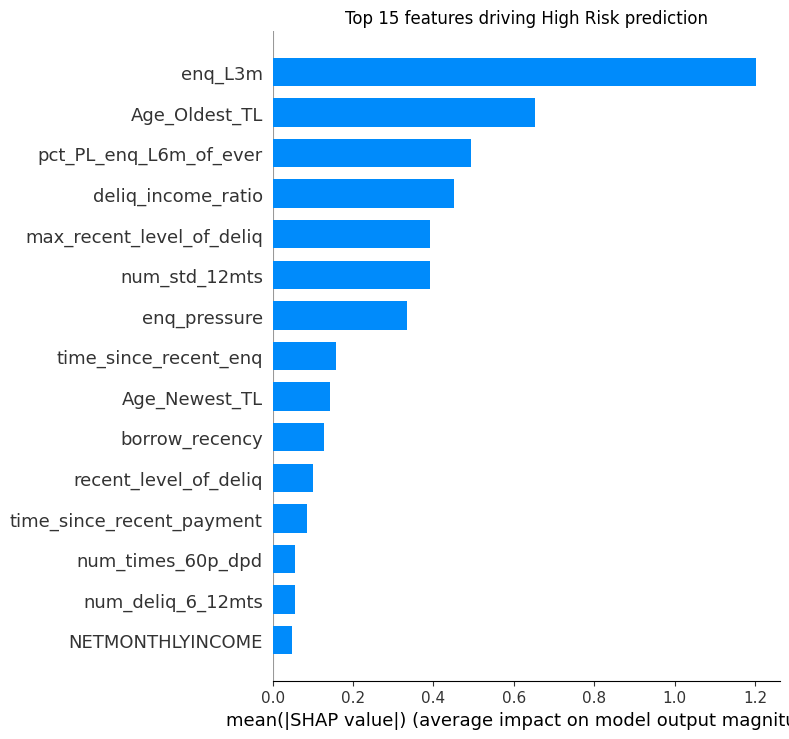

In [175]:
plt.figure()
shap.summary_plot(sv, x_test, plot_type="bar",
                  max_display=15, show=False)
plt.title("Top 15 features driving High Risk prediction")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=150)
plt.show()

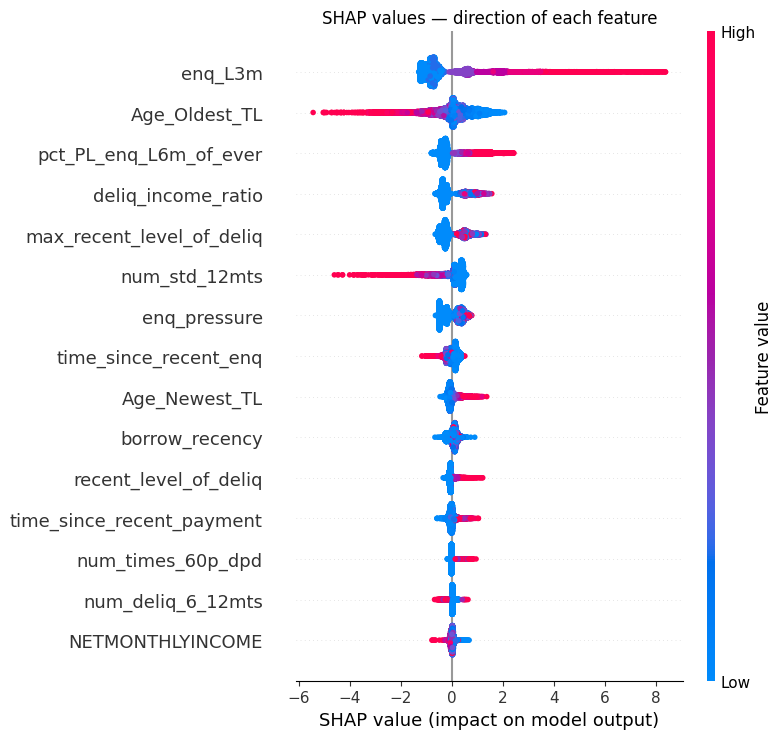

In [176]:
plt.figure()
shap.summary_plot(sv, x_test,
                  max_display=15, show=False)
plt.title("SHAP values — direction of each feature")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150)
plt.show()

Explaining borrower at index: 1
High-risk probability: 0.97


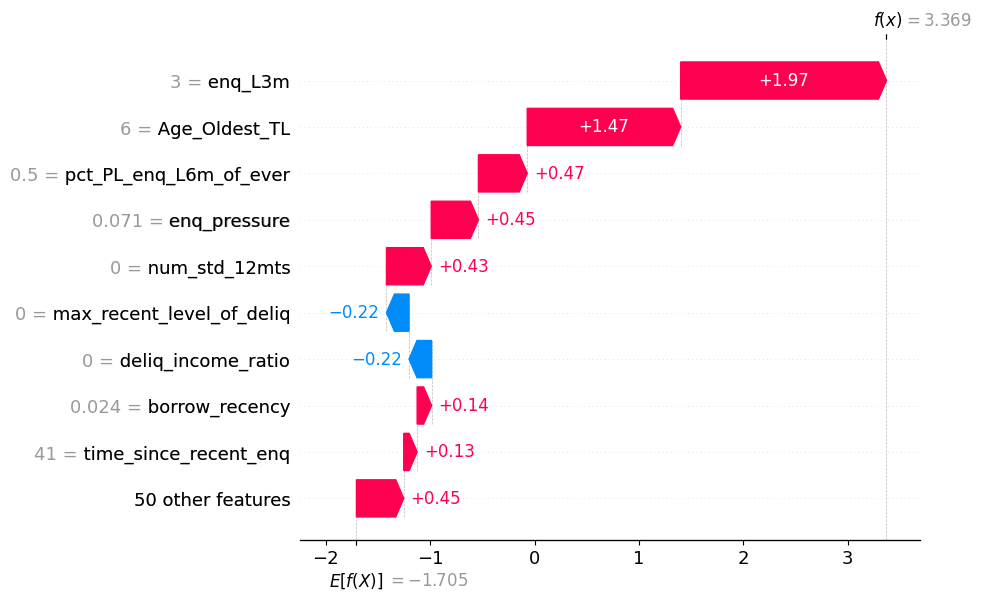

In [178]:
# Pick one high-risk borrower from test set
proba = lgbm.predict_proba(x_test)[:, 1]
high_risk_idx = np.where(proba >= 0.35)[0][0]

print(f"Explaining borrower at index: {high_risk_idx}")
print(f"High-risk probability: {proba[high_risk_idx]:.2f}")

shap.waterfall_plot(
    shap.Explanation(
        values=sv[high_risk_idx],
        base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
        data=x_test.iloc[high_risk_idx],
        feature_names=x_test.columns.tolist()
    )
)

Sir, here is the updated text with your language preserved and numbers updated from LightGBM results:

---

## What actually model is doing?

After seeing these plots here's my conclusion.

`enq_L3m` this feature is the major driver of the model around 1.20 SHAP value. Higher enquiry leads to risk according to Beeswarm plot. Which means if customer is enquiring for a loan a lot means it is risky to give him.

Age of oldest TL is the second major driver. If the age of oldest is greater then the customer is safer according to Beeswarm plot. Which means if the customer has oldest loan account, then this customer is safer for bank. Because bank has some information about him.

The third major driver of model is Percent enquiries PL in last 6 months around 0.50 SHAP value. According to Beeswarm plot higher personal loan enquiry leads to defaulting a loan.

Now using these top 3 feature importance explaining borrower at index 1:

Borrower has +1.97 SHAP value for `enq_L3m` which means he enquired a lot for a loan. And borrower enquired 3 times within 3 months. Age of oldest trade line value is 6. It means borrower opened account 6 months earlier. Borrower is newer for bank and has fewer credit history that's why the SHAP value goes towards +1.47 in red.

And also 50% time borrower enquiries about personal loan in last six months.

Concluding all this, borrower enquired 3 times for a loan in last 3 months and about personal loan borrower 50% times in last six months, which states borrower required urgent personal loan. Looking at these two info bank can give loan but with two conditions — at high rate of interest and only if bank needs to complete their goals. If we look at credit history of borrower, borrower has 6 month credit history. He is new to bank, so giving loan to borrower can be dangerous.

While looking at all 3 info borrower looks riskier. And model also predicts the value 3.369 which is far more away from the average of the dataset which is -1.705.

Model classifies this borrower as High Risk.

---

## Business Impact

Model is able to classify 80 risky customers out of 100 actual customers. Now to understand model performance I will take an example from dataset and assume bank gives 5 lakh rupees loan on an average. In dataset there are 2354 actually bad customers and out of that model is able to classify 1886 customers by which bank is able to save Rs. 377.20 Cr, but model is not able to capture 468 customers by which bank can lose up to Rs. 93.60 Cr. Rs. 93.60 Cr is a big number. So I will say before approving loan just make a quick glance on how many times does borrower enquired for loan in last 3 months and enquired for personal loan in last 6 months.

Looking at risk buckets, borrowers with very high risk score (75-100%) have 90.9% actual default rate — meaning almost every borrower in this bucket is genuinely risky. And borrowers in very low risk bucket (0-25%) have only 5.8% default rate — safe to approve directly.

Scaled to full 42,000 borrower portfolio, model provides net benefit of Rs. 187.65 Cr by avoiding major credit losses.

Overall the model provides a strong first filter, reducing manual review workload significantly while protecting the bank from majority of credit risk.

In [179]:
# ─── ASSUMPTIONS (standard banking assumptions) ───
avg_loan_amount    = 500000   # Rs. 5 lakhs average loan
loss_given_default = 0.40     # bank loses 40% of loan if borrower defaults
cost_per_rejection = 2000     # processing cost per wrongly rejected good borrower

# ─── GET PREDICTIONS AT THRESHOLD 0.35 ───
proba     = lgbm.predict_proba(x_test)[:, 1]
y_pred    = (proba >= 0.35).astype(int)
y_actual  = np.array(y_test)

# ─── CONFUSION MATRIX COMPONENTS ───
TP = ((y_pred == 1) & (y_actual == 1)).sum()  # correctly caught risky
FN = ((y_pred == 0) & (y_actual == 1)).sum()  # missed risky borrowers
FP = ((y_pred == 1) & (y_actual == 0)).sum()  # good borrowers wrongly rejected
TN = ((y_pred == 0) & (y_actual == 0)).sum()  # correctly approved good borrowers

print("=== CONFUSION MATRIX ===")
print(f"True Positives  (caught risky)       : {TP}")
print(f"False Negatives (missed risky)        : {FN}")
print(f"False Positives (wrongly rejected)    : {FP}")
print(f"True Negatives  (correctly approved)  : {TN}")

# ─── MONEY CALCULATIONS ───
loss_avoided     = TP * avg_loan_amount * loss_given_default
loss_not_avoided = FN * avg_loan_amount * loss_given_default
cost_of_fp       = FP * cost_per_rejection

net_benefit = loss_avoided - cost_of_fp

print("\n=== BUSINESS IMPACT (on test set of 8413 borrowers) ===")
print(f"Loss avoided by catching risky      : Rs. {loss_avoided:,.0f}")
print(f"Loss still at risk (missed)         : Rs. {loss_not_avoided:,.0f}")
print(f"Cost of wrongly rejecting good ones : Rs. {cost_of_fp:,.0f}")
print(f"Net benefit of model                : Rs. {net_benefit:,.0f}")

# ─── SCALE TO FULL PORTFOLIO ───
scale = 42000 / 8413   # full dataset / test set
print(f"\n=== SCALED TO FULL 42,000 BORROWER PORTFOLIO ===")
print(f"Estimated loss avoided              : Rs. {loss_avoided*scale:,.0f}")
print(f"Estimated net benefit               : Rs. {net_benefit*scale:,.0f}")
print(f"Net benefit in Crores               : Rs. {net_benefit*scale/1e7:.2f} Cr")

=== CONFUSION MATRIX ===
True Positives  (caught risky)       : 1886
False Negatives (missed risky)        : 468
False Positives (wrongly rejected)    : 655
True Negatives  (correctly approved)  : 5404

=== BUSINESS IMPACT (on test set of 8413 borrowers) ===
Loss avoided by catching risky      : Rs. 377,200,000
Loss still at risk (missed)         : Rs. 93,600,000
Cost of wrongly rejecting good ones : Rs. 1,310,000
Net benefit of model                : Rs. 375,890,000

=== SCALED TO FULL 42,000 BORROWER PORTFOLIO ===
Estimated loss avoided              : Rs. 1,883,085,701
Estimated net benefit               : Rs. 1,876,545,822
Net benefit in Crores               : Rs. 187.65 Cr


In [180]:
# ─── RISK BUCKET SUMMARY ───
results = pd.DataFrame({
    'Actual':    y_actual,
    'Predicted': y_pred,
    'Probability': proba
})

results['Risk_Bucket'] = pd.cut(
    results['Probability'],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Very Low (0-25%)', 'Low-Medium (25-50%)',
            'Medium-High (50-75%)', 'Very High (75-100%)']
)

summary = results.groupby('Risk_Bucket', observed=True).agg(
    Total_Borrowers=('Actual', 'count'),
    Actual_High_Risk=('Actual', 'sum'),
    Predicted_High_Risk=('Predicted', 'sum')
).reset_index()

summary['Default_Rate_%'] = (
    summary['Actual_High_Risk'] / summary['Total_Borrowers'] * 100
).round(1)

print("\n=== RISK BUCKET ANALYSIS ===")
print(summary.to_string(index=False))


=== RISK BUCKET ANALYSIS ===
         Risk_Bucket  Total_Borrowers  Actual_High_Risk  Predicted_High_Risk  Default_Rate_%
    Very Low (0-25%)             5409               314                    0             5.8
 Low-Medium (25-50%)              930               349                  467            37.5
Medium-High (50-75%)              627               375                  627            59.8
 Very High (75-100%)             1447              1316                 1447            90.9


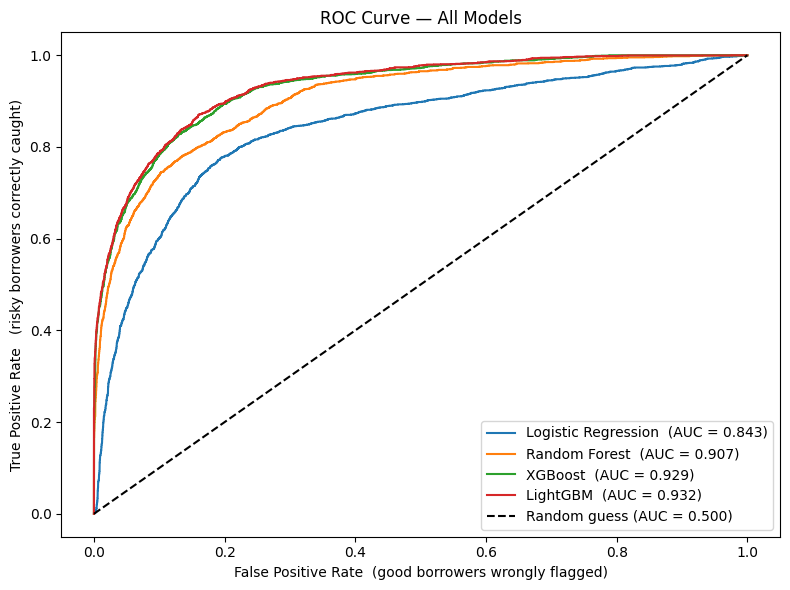

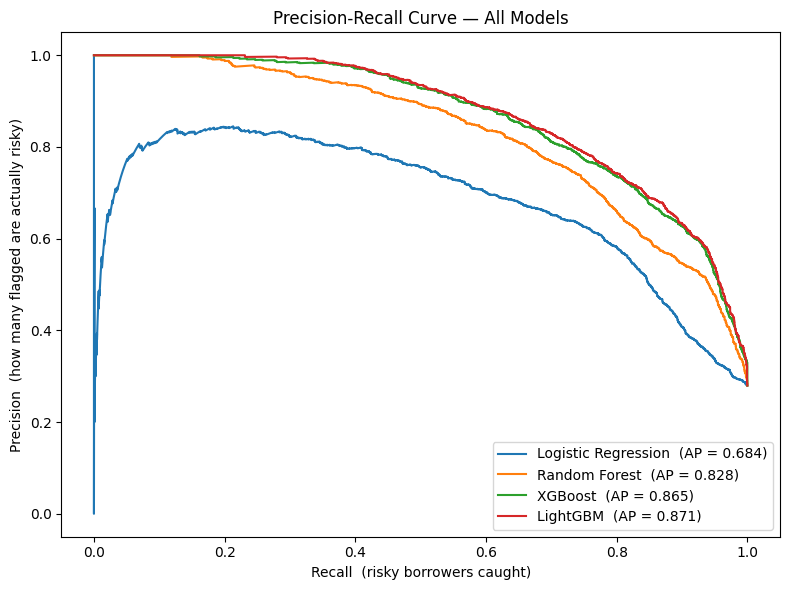

=== AUC SCORES ===
Logistic Regression        ROC-AUC: 0.8429   Avg Precision: 0.6839
Random Forest              ROC-AUC: 0.9069   Avg Precision: 0.8280
XGBoost                    ROC-AUC: 0.9288   Avg Precision: 0.8648
LightGBM                   ROC-AUC: 0.9318   Avg Precision: 0.8706


In [185]:
from sklearn.metrics import (roc_auc_score, roc_curve,
                             precision_recall_curve,
                             average_precision_score)
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities from all models
lr_proba  = lr.predict_proba(x_test)[:, 1]
rf_proba  = rf.predict_proba(x_test)[:, 1]
xgb_proba = xgb.predict_proba(x_test)[:, 1]
lgbm_proba = lgbm.predict_proba(x_test)[:, 1]

models = {
    'Logistic Regression': lr_proba,
    'Random Forest'      : rf_proba,
    'XGBoost'            : xgb_proba,
    'LightGBM'           : lgbm_proba
}

# ── Plot 1: ROC Curve ──
plt.figure(figsize=(8, 6))
for name, proba in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate  (good borrowers wrongly flagged)')
plt.ylabel('True Positive Rate   (risky borrowers correctly caught)')
plt.title('ROC Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# ── Plot 2: Precision-Recall Curve ──
plt.figure(figsize=(8, 6))
for name, proba in models.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(recall, precision, label=f"{name}  (AP = {ap:.3f})")

plt.xlabel('Recall  (risky borrowers caught)')
plt.ylabel('Precision  (how many flagged are actually risky)')
plt.title('Precision-Recall Curve — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()
# ── Print AUC scores ──
print("=== AUC SCORES ===")
for name, proba in models.items():
    auc = roc_auc_score(y_test, proba)
    ap  = average_precision_score(y_test, proba)
    print(f"{name:25s}  ROC-AUC: {auc:.4f}   Avg Precision: {ap:.4f}")

In [188]:
import pickle
# Define the filename for the model
lgbm_model = 'LightGBM_model.pkl'

# Use pickle to dump the trained model object into a file
with open(lgbm_model, 'wb') as file:
    pickle.dump(lgbm, file)

print(f"Model successfully saved as '{lgbm_model}'")

Model successfully saved as 'LightGBM_model.pkl'


In [186]:
import pickle
median_values = x_train.median().to_dict()

with open('median_defaults.pkl', 'wb') as f:
    pickle.dump(median_values, f)

print("Saved defaults for", len(median_values), "features")

Saved defaults for 59 features


In [187]:
import pickle

# 1. Save feature order
feature_order = list(x_train.columns)
with open('feature_order.pkl', 'wb') as f:
    pickle.dump(feature_order, f)

# 2. Verify
print("Total features:", len(feature_order))
print("Features:", feature_order)

Total features: 59
Features: ['pct_tl_open_L6M', 'pct_tl_closed_L6M', 'Tot_TL_closed_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'CC_TL', 'Home_TL', 'PL_TL', 'Secured_TL', 'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL', 'time_since_recent_payment', 'max_recent_level_of_deliq', 'num_deliq_6_12mts', 'num_times_60p_dpd', 'num_std_12mts', 'num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_12mts', 'num_lss', 'recent_level_of_deliq', 'CC_enq_L12m', 'PL_enq_L12m', 'time_since_recent_enq', 'enq_L3m', 'NETMONTHLYINCOME', 'Time_With_Curr_Empr', 'CC_Flag', 'PL_Flag', 'pct_PL_enq_L6m_of_ever', 'pct_CC_enq_L6m_of_ever', 'HL_Flag', 'GL_Flag', 'EDUCATION', 'MARITALSTATUS_Married', 'MARITALSTATUS_Single', 'GENDER_F', 'GENDER_M', 'last_prod_enq2_AL', 'last_prod_enq2_CC', 'last_prod_enq2_ConsumerLoan', 'last_prod_enq2_HL', 'last_prod_enq2_PL', 'last_prod_enq2_others', 'first_prod_enq2_AL', 'first_prod_enq2_CC', 'first_prod_enq2_ConsumerLoan', 'first_prod_enq2_HL', 'first_p